<h1>
<center>基于注意力的时空图卷积网络
用于交通流预测</center>
</h1>

在本 Notebook 中，我们将深入探讨“基于注意力的时空图卷积网络”（Attentional Temporal Graph Convolution Networks）。这一模型集众多前沿技术于一身，巧妙地融合了注意力机制、基于深度学习的时序分析（即时序数据处理）以及图卷积网络。本 Notebook 中的代码是对原论文《基于注意力的时空图卷积网络用于交通流预测》（论文链接：https://ojs.aaai.org/index.php/AAAI/article/view/3881）代码的重写；在讲解过程中，我们将引用该论文中的相关论述及部分代码片段。此外，本 Notebook 所使用的数据集已在上一篇 Notebook《用于深度学习项目的交通数据预处理》（Processing traffic data for deep learning projects）中完成准备。

In [1]:
import os
from time import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx



import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


DEVICE = torch.device('cpu')
print("Using device:", DEVICE)


from tensorboardX import SummaryWriter
sw = SummaryWriter(logdir='.', flush_secs=5)

import math
from typing import Optional, List, Union

import torch
import torch.nn as nn
from torch.nn import Parameter
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.typing import OptTensor
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.transforms import LaplacianLambdaMax
from torch_geometric.utils import remove_self_loops, add_self_loops, get_laplacian
from torch_geometric.utils import to_dense_adj

Using device: cpu


# 加载数据（时间部分）
如前一个 notebook 所述，数据划分如下：

10181 个数据/目标示例将作为训练集（35 天）

3394 个数据/目标示例将作为验证集（12 天）

3394 个数据/目标示例将作为测试集（12 天）

每个预测/目标小时示例的形状为 (12, 307, 3)，数据将以 32 的批量加载

其形状将为 (32, 12, 307, 3)

In [6]:
def load_graphdata_channel1(graph_signal_matrix_filename, num_of_hours, num_of_days, num_of_weeks, batch_size,
                            shuffle=True, DEVICE=torch.device('cpu')):
    '''
    :param graph_signal_matrix_filename: str
    :param num_of_hours: int
    :param num_of_days: int
    :param num_of_weeks: int
    :param DEVICE:
    :param batch_size: int
    :return:
    three DataLoaders, each dataloader contains:
    test_x_tensor: (B, N_nodes, in_feature, T_input)
    test_decoder_input_tensor: (B, N_nodes, T_output)
    test_target_tensor: (B, N_nodes, T_output)
    '''

    file = os.path.basename(graph_signal_matrix_filename).split('.')[0]
    filename = os.path.join(file + '_r' + str(num_of_hours) + '_d' + str(num_of_days) + '_w' + str(num_of_weeks)) +'_astcgn'
    print('load file:', filename)

    file_data = np.load(filename + '.npz')
    train_x = file_data['train_x']  # (10181, 307, 3, 12)
    train_x = train_x[:, :, 0:1, :]
    train_target = file_data['train_target']  # (10181, 307, 12)

    val_x = file_data['val_x']
    val_x = val_x[:, :, 0:1, :]
    val_target = file_data['val_target']

    test_x = file_data['test_x']
    test_x = test_x[:, :, 0:1, :]
    test_target = file_data['test_target']

    mean = file_data['mean'][:, :, 0:1, :]  # (1, 1, 3, 1)
    std = file_data['std'][:, :, 0:1, :]  # (1, 1, 3, 1)

    # ------- train_loader -------
    train_x_tensor = torch.from_numpy(train_x).type(torch.FloatTensor).to(DEVICE)  # (B, N, F, T)
    train_target_tensor = torch.from_numpy(train_target).type(torch.FloatTensor).to(DEVICE)  # (B, N, T)
    train_dataset = torch.utils.data.TensorDataset(train_x_tensor, train_target_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)

    # ------- val_loader -------
    val_x_tensor = torch.from_numpy(val_x).type(torch.FloatTensor).to(DEVICE)  # (B, N, F, T)
    val_target_tensor = torch.from_numpy(val_target).type(torch.FloatTensor).to(DEVICE)  # (B, N, T)
    val_dataset = torch.utils.data.TensorDataset(val_x_tensor, val_target_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # ------- test_loader -------
    test_x_tensor = torch.from_numpy(test_x).type(torch.FloatTensor).to(DEVICE)  # (B, N, F, T)
    test_target_tensor = torch.from_numpy(test_target).type(torch.FloatTensor).to(DEVICE)  # (B, N, T)
    test_dataset = torch.utils.data.TensorDataset(test_x_tensor, test_target_tensor)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # print
    print('train:', train_x_tensor.size(), train_target_tensor.size())
    print('val:', val_x_tensor.size(), val_target_tensor.size())
    print('test:', test_x_tensor.size(), test_target_tensor.size())

    return train_loader, train_target_tensor, val_loader, val_target_tensor, test_loader, test_target_tensor, mean, std


In [7]:
graph_signal_matrix_filename = 'PEMS04.npz'
batch_size = 32
num_of_weeks = 0
num_of_days = 0
num_of_hours = 1

train_loader, train_target_tensor, val_loader, val_target_tensor, test_loader, test_target_tensor, _mean, _std = load_graphdata_channel1(
    graph_signal_matrix_filename, num_of_hours, num_of_days, num_of_weeks, batch_size)

load file: PEMS04_r1_d0_w0_astcgn
train: torch.Size([10181, 307, 1, 12]) torch.Size([10181, 307, 12])
val: torch.Size([3394, 307, 1, 12]) torch.Size([3394, 307, 12])
test: torch.Size([3394, 307, 1, 12]) torch.Size([3394, 307, 12])


# 加载图（空间部分）

在我们的情况下，图是交通网络（字面意义上，检测器（传感器）之间的网络连接应用于交通网络）

在我们的示例中，我们有 307 个检测器，当它们在空间上连接时，就构成了我们正在研究的交通网络。


In [8]:
def get_adjacency_matrix(distance_df_filename, num_of_vertices, id_filename=None):
    '''
    Parameters
    ----------
    distance_df_filename: str, path of the csv file contains edges information
    num_of_vertices: int, the number of vertices
    Returns
    ----------
    A: np.ndarray, adjacency matrix
    '''
    if 'npy' in distance_df_filename:  # false
        adj_mx = np.load(distance_df_filename)
        return adj_mx, None
    else:
        
        #--------------------------------------------- read from here
        import csv
        A = np.zeros((int(num_of_vertices), int(num_of_vertices)),dtype=np.float32)
        distaneA = np.zeros((int(num_of_vertices), int(num_of_vertices)), dtype=np.float32)

        #------------ Ignore
        if id_filename: # false
            with open(id_filename, 'r') as f:
                id_dict = {int(i): idx for idx, i in enumerate(f.read().strip().split('\n'))}  # 把节点id（idx）映射成从0开始的索引

            with open(distance_df_filename, 'r') as f:
                f.readline()
                reader = csv.reader(f)
                for row in reader:
                    if len(row) != 3:
                        continue
                    i, j, distance = int(row[0]), int(row[1]), float(row[2])
                    A[id_dict[i], id_dict[j]] = 1
                    distaneA[id_dict[i], id_dict[j]] = distance
            return A, distaneA

        else:
         #-------------Continue reading
            with open(distance_df_filename, 'r') as f:
                f.readline()
                reader = csv.reader(f)
                for row in reader:
                    if len(row) != 3:
                        continue
                    i, j, distance = int(row[0]), int(row[1]), float(row[2])
                    A[i, j] = 1
                    distaneA[i, j] = distance
            return A, distaneA

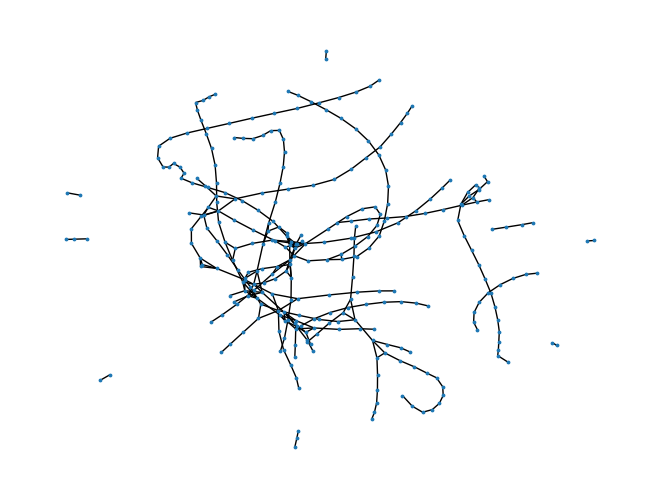

In [9]:
id_filename = None
adj_filename = 'PEMS04.csv'
num_of_vertices = 307
adj_mx, distance_mx = get_adjacency_matrix(adj_filename, num_of_vertices, id_filename) #  adj_mx and distance_mx (307, 307)

rows, cols = np.where(adj_mx == 1)
edges = zip(rows.tolist(), cols.tolist())
gr = nx.Graph()
gr.add_edges_from(edges)
nx.draw(gr, node_size=3)
plt.show()
rows, cols = np.where(adj_mx == 1)
edges = zip(rows.tolist(), cols.tolist())
edge_index_data = torch.LongTensor(np.array([rows, cols])).to(DEVICE)

# 构建模型

# 模型层

## 时间注意力层

在时间维度上，不同时间片之间的交通状况存在相关性，这些相关性在不同情况下也是变化的。同样，我们使用注意力机制自适应地附加不同的重要性给数据。

<img src="https://i.ibb.co/KwXCqJx/temp-attention.png" width="400">



理解这个方程：

它学习关注（聚焦）输入时间段中的哪一部分。在我们的例子中，我们有 12 个时间点，所以它将生成 12x12 的权重。

<img src="https://i.ibb.co/NZ4fh4k/atten2.jpg" width="400">

## 空间注意力层

在空间维度上，不同位置的交通状况相互影响，且这种相互影响是高度动态的。在这里，我们使用注意力机制（Feng et al. 2017）自适应地捕捉空间维度中节点之间的动态相关性。

<img src="https://i.ibb.co/PGnj4MR/spatial1.png" width="400">

<img src="https://i.ibb.co/G5jkKvr/spatial2.png" width="400">


与时间注意力相同；然而，在这里注意力权重将在图卷积层内使用



<img src="https://i.ibb.co/stTfTFM/spat2.jpg" width="400">


## 空间部分的谱图分析
由于空间部分由图表示，我们将应用图卷积来聚合邻居节点的消息。我们将使用的图卷积类型是谱卷积。

* 在谱图分析中，图由其对应的拉普拉斯矩阵表示。
* 图结构的性质可以通过分析拉普拉斯矩阵及其特征值获得

* 图的拉普拉斯矩阵定义为 L = D − A

* 其归一化形式为 L = I − ((1/ sqrt(D) A ( 1/ sqrt(D))

其中 A 是邻接矩阵，I 是单位矩阵，度矩阵 D（对角矩阵，由节点度组成，在对角线上）

拉普拉斯矩阵的特征值分解为 L = U*Λ*(U.transpose())，其中 Λ = diag([λ0, ..., λN −1]) 是对角矩阵，U 是傅里叶基。

U 是正交矩阵。

图卷积是通过使用在傅里叶域中对角化的线性算子来替代经典卷积算子而实现的卷积操作。

然而，当图的规模较大时，直接对拉普拉斯矩阵进行特征值分解是昂贵的。因此，采用切比雪夫多项式来近似但有效地解决这个问题。




# ASTGCN 模型结构

模型由两个 ASTGCN 块和最后一个最终层组成

原始输入 x (input) 形状为 (32, 307, 1, 12) -Block1> (32, 307, 64, 12) -Block2> (32, 307, 64, 12) -permute-> (32, 12, 307,64) 
            # -final_conv-> (32, 12, 307, 1) -reshape-> (32,307,12) "目标数据"

该模型是三个具有相同结构的独立组件的融合，分别设计用于模拟历史数据的近期、日周期和周周期依赖关系。这在前一个 notebook 中讨论过（https://www.kaggle.com/elmahy/processing-traffic-data-for-deep-learning-projects）。

但在我们的情况下，我们将只关注近期段（最近一小时段），即 X_h

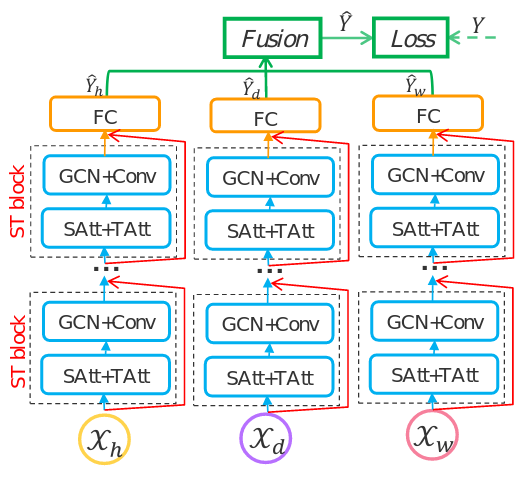

In [11]:
from torch_geometric_temporal.nn.attention import ASTGCN   # For information about the architecture check the source code

# 初始化 ASTGCN 模型


In [12]:
nb_block = 2
in_channels = 1
K = 3
nb_chev_filter = 64
nb_time_filter = 64
time_strides = num_of_hours
num_for_predict = 12
len_input = 12
#L_tilde = scaled_Laplacian(adj_mx)
#cheb_polynomials = [torch.from_numpy(i).type(torch.FloatTensor).to(DEVICE) for i in cheb_polynomial(L_tilde, K)]
net = ASTGCN( nb_block, in_channels, K, nb_chev_filter, nb_time_filter, time_strides, num_for_predict, len_input, num_of_vertices).to(DEVICE)

print(net)


ASTGCN(
  (_blocklist): ModuleList(
    (0): ASTGCNBlock(
      (_temporal_attention): TemporalAttention()
      (_spatial_attention): SpatialAttention()
      (_chebconv_attention): ChebConvAttention(1, 64, K=3, normalization=None)
      (_time_convolution): Conv2d(64, 64, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
      (_residual_convolution): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
      (_layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (1): ASTGCNBlock(
      (_temporal_attention): TemporalAttention()
      (_spatial_attention): SpatialAttention()
      (_chebconv_attention): ChebConvAttention(64, 64, K=3, normalization=None)
      (_time_convolution): Conv2d(64, 64, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
      (_residual_convolution): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (_layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (_final_conv): Conv2d(12, 12, kernel_size=(1, 64), strid

In [13]:
#------------------------------------------------------
learning_rate = 0.001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

print('Net\'s state_dict:')
total_param = 0
for param_tensor in net.state_dict():
    print(param_tensor, '\t', net.state_dict()[param_tensor].size(), '\t', net.state_dict()[param_tensor].device)
    total_param += np.prod(net.state_dict()[param_tensor].size())
print('Net\'s total params:', total_param)
#--------------------------------------------------
print('Optimizer\'s state_dict:')
for var_name in optimizer.state_dict():
    print(var_name, '\t', optimizer.state_dict()[var_name])


Net's state_dict:
_blocklist.0._temporal_attention._U1 	 torch.Size([307]) 	 cpu
_blocklist.0._temporal_attention._U2 	 torch.Size([1, 307]) 	 cpu
_blocklist.0._temporal_attention._U3 	 torch.Size([1]) 	 cpu
_blocklist.0._temporal_attention._be 	 torch.Size([1, 12, 12]) 	 cpu
_blocklist.0._temporal_attention._Ve 	 torch.Size([12, 12]) 	 cpu
_blocklist.0._spatial_attention._W1 	 torch.Size([12]) 	 cpu
_blocklist.0._spatial_attention._W2 	 torch.Size([1, 12]) 	 cpu
_blocklist.0._spatial_attention._W3 	 torch.Size([1]) 	 cpu
_blocklist.0._spatial_attention._bs 	 torch.Size([1, 307, 307]) 	 cpu
_blocklist.0._spatial_attention._Vs 	 torch.Size([307, 307]) 	 cpu
_blocklist.0._chebconv_attention._weight 	 torch.Size([3, 1, 64]) 	 cpu
_blocklist.0._chebconv_attention._bias 	 torch.Size([64]) 	 cpu
_blocklist.0._time_convolution.weight 	 torch.Size([64, 64, 1, 3]) 	 cpu
_blocklist.0._time_convolution.bias 	 torch.Size([64]) 	 cpu
_blocklist.0._residual_convolution.weight 	 torch.Size([64, 1, 1,

# 定义损失函数

 1. masked_mae

In [14]:
def masked_mae(preds, labels, null_val=np.nan):
    if np.isnan(null_val):
        mask = ~torch.isnan(labels)
    else:
        mask = (labels != null_val)
    mask = mask.float()
    mask /= torch.mean((mask))
    mask = torch.where(torch.isnan(mask), torch.zeros_like(mask), mask)
    loss = torch.abs(preds - labels)
    loss = loss * mask
    loss = torch.where(torch.isnan(loss), torch.zeros_like(loss), loss)
    return torch.mean(loss)


In [15]:
masked_flag=0
criterion = nn.L1Loss().to(DEVICE)
criterion_masked = masked_mae
loss_function = 'mse'

metric_method = 'unmask'
missing_value=0.0


if loss_function=='masked_mse':
    criterion_masked = masked_mse         #nn.MSELoss().to(DEVICE)
    masked_flag=1
elif loss_function=='masked_mae':
    criterion_masked = masked_mae
    masked_flag = 1
elif loss_function == 'mae':
    criterion = nn.L1Loss().to(DEVICE)
    masked_flag = 0
elif loss_function == 'rmse':
    criterion = nn.MSELoss().to(DEVICE)
    masked_flag= 0

In [16]:
def compute_val_loss_mstgcn(net, val_loader, criterion,  masked_flag,missing_value,sw, epoch, edge_index_data, limit=None):
    '''
    for rnn, compute mean loss on validation set
    :param net: model
    :param val_loader: torch.utils.data.utils.DataLoader
    :param criterion: torch.nn.MSELoss
    :param sw: tensorboardX.SummaryWriter
    :param global_step: int, current global_step
    :param limit: int,
    :return: val_loss
    '''
    net.train(False)  # ensure dropout layers are in evaluation mode
    with torch.no_grad():
        val_loader_length = len(val_loader)  # nb of batch
        tmp = []  # batch loss
        for batch_index, batch_data in enumerate(val_loader):
            encoder_inputs, labels = batch_data
            outputs = net(encoder_inputs, edge_index_data)
            if masked_flag:
                loss = criterion(outputs, labels, missing_value)
            else:
                loss = criterion(outputs, labels)
            tmp.append(loss.item())
            if batch_index % 100 == 0:
                print('validation batch %s / %s, loss: %.2f' % (batch_index + 1, val_loader_length, loss.item()))
            if (limit is not None) and batch_index >= limit:
                break

        validation_loss = sum(tmp) / len(tmp)
        sw.add_scalar('validation_loss', validation_loss, epoch)
    return validation_loss

In [17]:
global_step = 0
best_epoch = 0
best_val_loss = np.inf
start_time= time()

In [ ]:
# train model
for epoch in range(20):
    params_filename = os.path.join('./', 'epoch_%s.params' % epoch)
    masked_flag = 1
    if masked_flag:
        val_loss = compute_val_loss_mstgcn(net, val_loader, criterion_masked, masked_flag,missing_value,sw, epoch,edge_index_data)
    else:
        val_loss = compute_val_loss_mstgcn(net, val_loader, criterion, masked_flag, missing_value, sw, epoch,edge_index_data)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(net.state_dict(), params_filename)
        print('save parameters to file: %s' % params_filename)

    net.train()  # ensure dropout layers are in train mode

    for batch_index, batch_data in enumerate(train_loader):
        encoder_inputs, labels = batch_data   # encoder_inputs torch.Size([32, 307, 1, 12])  label torch.Size([32, 307, 12])
        optimizer.zero_grad()
        outputs = net(encoder_inputs, edge_index_data) # torch.Size([32, 307, 12])

        if masked_flag:
            loss = criterion_masked(outputs, labels,missing_value)
        else :
            loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        training_loss = loss.item()
        global_step += 1
        sw.add_scalar('training_loss', training_loss, global_step)

        if global_step % 200 == 0:
            print('global step: %s, training loss: %.2f, time: %.2fs' % (global_step, training_loss, time() - start_time))

validation batch 1 / 107, loss: 277.89
validation batch 101 / 107, loss: 334.18
save parameters to file: ./epoch_0.params


In [ ]:
net.train(False)  # ensure dropout layers are in evaluation mode
with torch.no_grad():
    test_loader_length = len(test_loader)  # nb of batch
    tmp = []  # batch loss
    for batch_index, batch_data in enumerate(test_loader):
        encoder_inputs, labels = batch_data
        outputs = net(encoder_inputs, edge_index_data)
        loss = criterion(outputs, labels)
        tmp.append(loss.item())
        if batch_index % 100 == 0:
            print('test_loss batch %s / %s, loss: %.2f' % (batch_index + 1, test_loader_length, loss.item()))


    test_loss = sum(tmp) / len(tmp)
    sw.add_scalar('test_loss', test_loss, epoch)
print(test_loss)

# 选择一个随机时间点并可视化前 50 个检测器的预测结果

In [ ]:
sample_output = outputs[0]  # prediction
sample_labels = labels[0] # truth
print(sample_output.shape, sample_labels.shape)

In [ ]:
from matplotlib.pyplot import figure

figure(figsize=(30,4), dpi=80)
for i in range(50):
    new_i = i * 12
    plt.plot(range(0+new_i,12+new_i),sample_output[i].detach().cpu().numpy(), color = 'red')
    plt.plot(range(0+new_i,12+new_i),sample_labels[i].cpu().numpy(), color='blue')
plt.show()